<a href="https://colab.research.google.com/github/simone-cappelletti/ai-sample-projects-library/blob/main/RealEstateAI_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progetto
**RealEstateAI Solutions** si propone di ottimizzare la valutazione dei prezzi immobiliari attraverso l'uso di tecniche avanzate di regolarizzazione in modelli di regressione lineare. L'obiettivo è fornire previsioni di prezzo più accurate e affidabili, riducendo il rischio di overfitting e migliorando la capacità di generalizzazione del modello.

Nel settore immobiliare, ottenere stime precise dei prezzi delle proprietà è cruciale per prendere decisioni informate. Tuttavia, i modelli di regressione lineare tradizionali possono soffrire di overfitting, compromettendo l'accuratezza delle previsioni. È necessario esplorare metodi di regolarizzazione efficaci per migliorare le performance predittive e gestire la complessità del modello.

Implementando e confrontando metodi di regolarizzazione come Lasso, Ridge e Elastic Net, RealEstateAI Solutions offrirà un sistema in grado di fornire previsioni di prezzo immobiliari più accurate e stabili. Questo permetterà agli agenti immobiliari e agli investitori di prendere decisioni basate su dati più affidabili, aumentando la loro competitività nel mercato.

# Requisiti
1. Preparazione del dataset:
    - Caricamento e preprocessamento dei dati sui prezzi immobiliari.
    - Gestione dei valori mancanti, codifica delle variabili categoriche e normalizzazione/scalatura dei dati.

2. Implementazione dei Modelli di Regressione:
    - **Ridge Regression**: Implementazione e addestramento del modello con   regolarizzazione Ridge.
    - **Lasso Regression**: Implementazione e addestramento del modello con   regolarizzazione Lasso.
    - **Elastic Net Regression**: Implementazione e addestramento del modello con regolarizzazione Elastic Net.

3. Valutazione delle Performance:
    - Utilizzo di tecniche di validazione incrociata.
    - Calcolo del Mean Squared Error (MSE) per ciascun modello.
    - Confronto della complessità dei modelli valutando il numero di coefficienti   non nulli.
    - Analisi e confronto dei risultati dei vari metodi di regolarizzazione.

4. Visualizzazione dei Risultati:
    - Creazione di grafici per visualizzare e confrontare le performance dei  modelli.
    - Visualizzazione della distribuzione dei residui per valutare l'adeguatezza del modello.

# Dataset
Il dataset è disponibile qui: https://proai-datasets.s3.eu-west-3.amazonaws.com/housing.csv (liberamente tratto dal seguente dataset: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset)

- **Price**: il prezzo, il target da prevedere
- **Area**: superficie dell’immobile
- **Bedrooms**: numero di camere da letto
- **Bathrooms**: numero di bagni
- **Stories**: numero di piani
- **Mainroad**: vale 1 se l’immobile affaccia su una strada principale, 0 altrimenti
- **guestroom**: vale 1 se l’immobile ha una stanza degli ospiti, 0 altrimenti
- **basement**: vale 1 se l’immobile ha un seminterrato, 0 altrimenti
- **hotwaterheating**: vale 1 se l’immobile ha una caldaia, 0 altrimenti
- **airconditioning**: vale 1 se l’immobile ha l’aria condizionata, 0 altrimenti
- **parking**: numero di parcheggi
- **prefarea**: vale 1 se l’immobile è in una zona prestigiosa, 0 altrimenti
- **Furnishingstatus**: vale 0 se l’immobile non è arredato, 1 se è parzialmente - arredato, 2 se è completamente arredato

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# Constants
DATASET_URL="https://proai-datasets.s3.eu-west-3.amazonaws.com/"
PRICE_FEATURE="price"
AREA_FEATURE="area"
BATHROOMS_FEATURE="bathrooms"
SEED=0
NEG_MEAN_SQUARED_ERROR="neg_mean_squared_error"

# Preparazione del dataset

## Caricamento dataset

In [ ]:
df = pd.read_csv(DATASET_URL + "housing.csv")

## Analisi esplorativa

In [ ]:
print(df.head())

print("\nShape dataset:", df.shape)

print("\nTipi colonne:")
print(df.dtypes)

print("\nStatistiche descrittive:")
print(df.describe(include="all"))

print("\nValori mancanti per colonna:")
print(df.isna().sum().sort_values(ascending=False))

print("\nRighe duplicate:", df.duplicated().sum())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0                 1  
1                 1  
2                 2  
3                 1  
4                 1  

Shape dataset: (545, 13)


Noto che:
- Ci sono abbastanza feature (13 in totale, 12 escludendo la feature target), ma non farò feature selection manualmente tramite matrice di correlazione perché lascerò Lasso e Ridge fare feature selection in autonomia.
- Tutte le feature sono rappresentate con valori numerici quindi non ho bisogno di particolari encoding.
- Il dataset è abbastanza grande (500+ righe) quindi applicherei una tecnica semplice come Hold-out per dividere il dataset in train/test (lasciando i parametri di default di sklearn 80/20).
- Non ci sono dati mancanti.
- Non ci sono righe duplicate.

Proseguo e:
- Plotto le distribuzioni delle features.

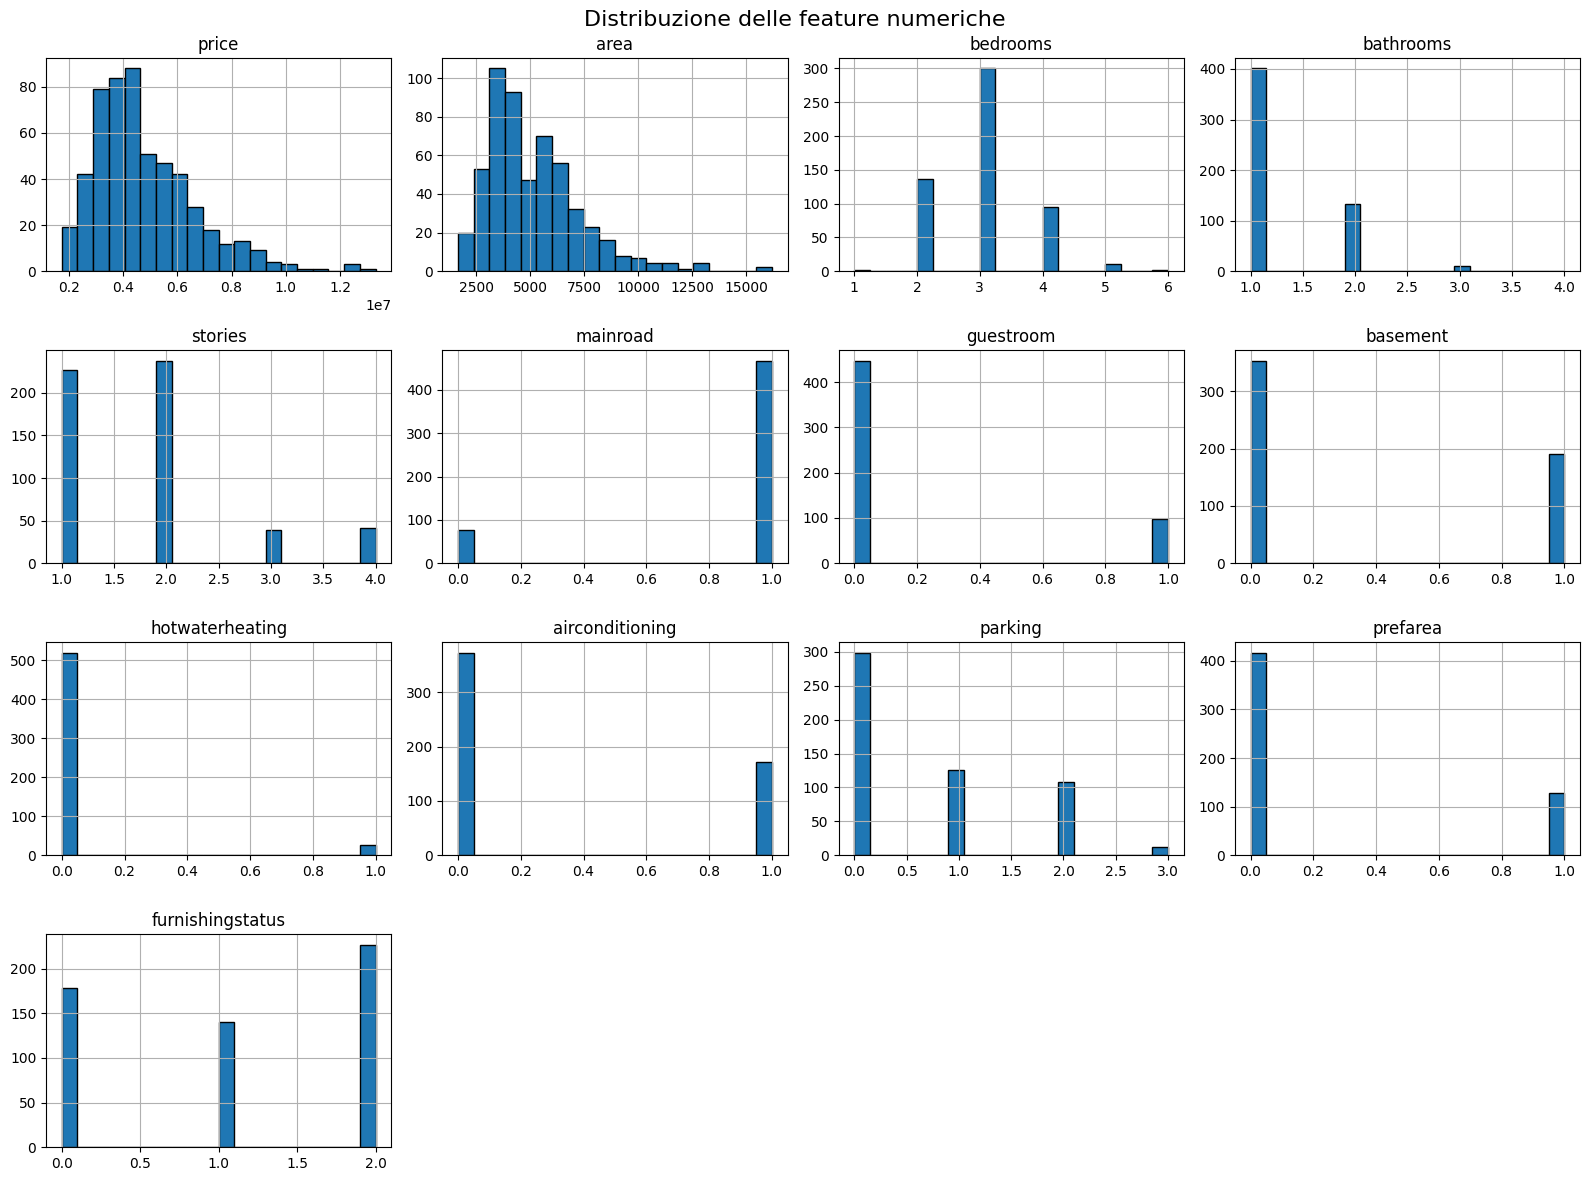

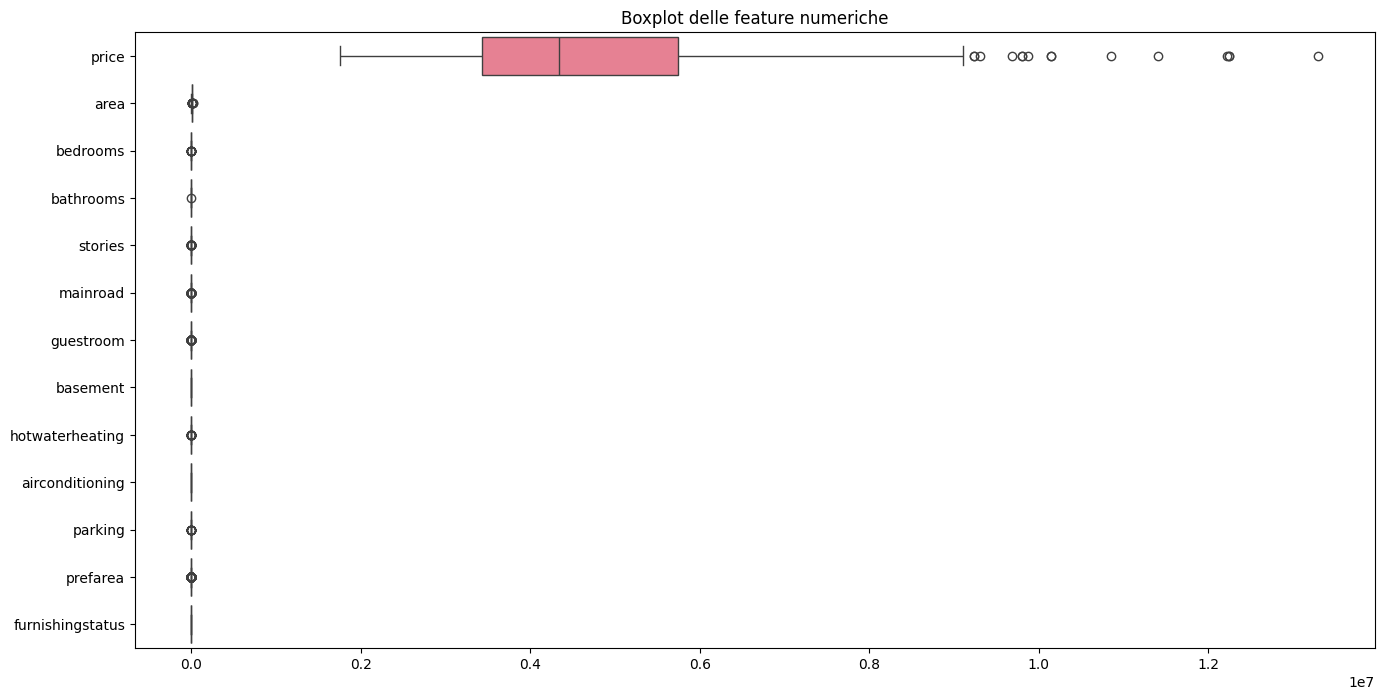

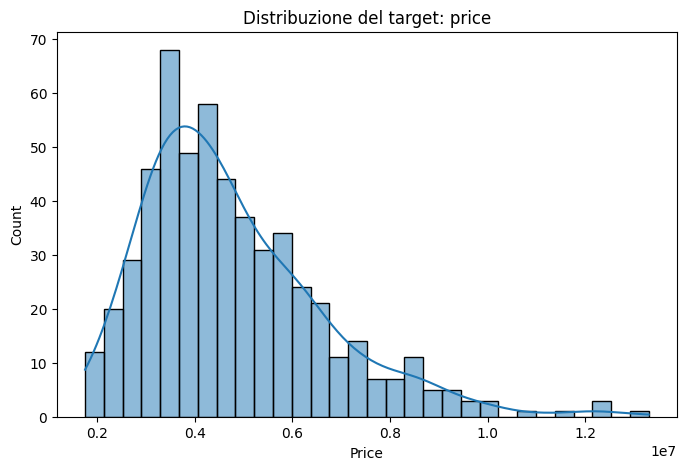

In [ ]:
columns = df.columns.tolist()

# Istogrammi
df[columns].hist(figsize=(16, 12), bins=20, edgecolor="black")
plt.suptitle("Distribuzione delle feature numeriche", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(16, 8))
sns.boxplot(data=df[columns], orient="h")
plt.title("Boxplot delle feature numeriche")
plt.show()

# Distribuzione del target
plt.figure(figsize=(8, 5))
sns.histplot(df[PRICE_FEATURE], kde=True, bins=30)
plt.title("Distribuzione del target: price")
plt.xlabel("Price")
plt.show()

Non noto cose particolari come:
- Feature particolarmente assimmetriche o outlier/errori.

Proseguo verificando le feature più correlate tramite matrice di correlazione:

<Axes: >

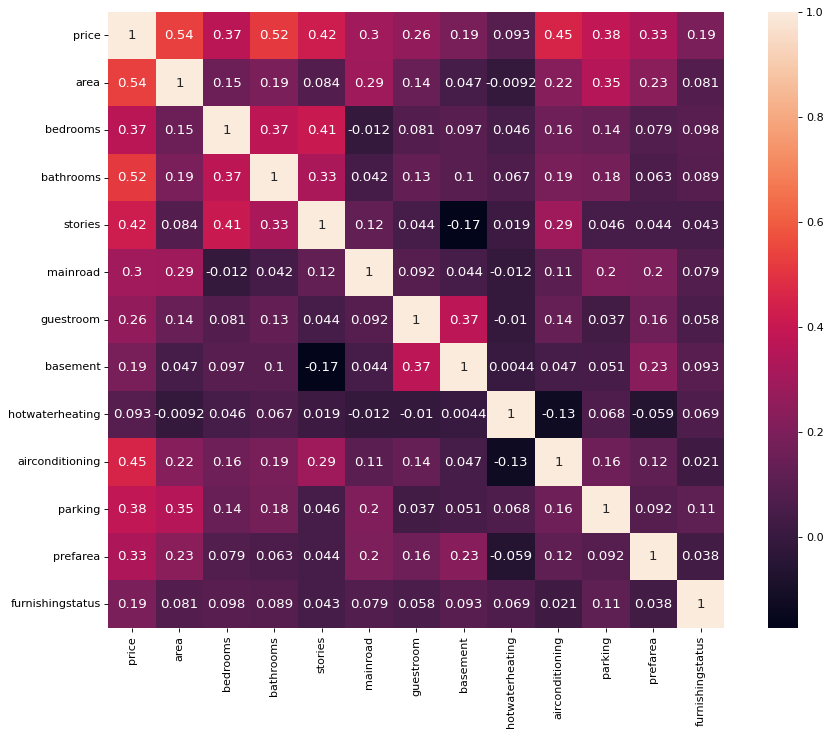

In [ ]:
# Matrice di correlazione
plt.figure(figsize=(14, 10), dpi=80)

correlation_matrix = df.corr()

sns.heatmap(
  correlation_matrix,
  cbar=True,
  square=True,
  yticklabels=df.columns,
  xticklabels=df.columns,
  annot=True,
  annot_kws={'size':12})

Noto che non ci sono feature particolarmente correlate in positivo o in negativo ma le più correlate sono:
- area
- bathrooms

Proseguo dunque con:
- Hold-out

In [ ]:
X = df.drop(columns=[PRICE_FEATURE])
y = df[PRICE_FEATURE]

# Hold-out
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=SEED)

# Implementazione dei Modelli di Regressione

Ora applico:
- Ridge
- Lasso
- ElasticNet

Siccome voglio trovare il miglior valore del parametro **alpha** per ogni modello:
- Stabilisco una serie di valori di alpha iniziali da voler testare.
- Suddivido ulteriormente il dataset di train tramite cross-validation (utilizzo i 5-fold di default del metodo). In questo modo evito overfitting sul dataset di train.
- Applico tutti i modelli ad ogni fold iterando ogni valore di alpha.
- Nel caso di ElasticNet, provo anche differenti valori di **l1_ratio**.

Inoltre le features sono su scale differenti (vedi "area" ad esempio), quindi applicherei la standardizzazione Z-score singolarmente ad ogni fold tramite pipeline.

In [ ]:
alphas = [0.01, 0.1, 1, 10, 100]
l1_ratios = [0.2, 0.5, 0.8]

best_lasso_score = float("inf")
best_ridge_score = float("inf")
best_elasticnet_score = float("inf")

best_lasso_alpha = None
best_ridge_alpha = None
best_elasticnet_alpha = None

best_elasticnet_l1_ratio = None

# Log dei risultati delle varie iterazioni
results = []

for alpha in alphas:
  # Regolarizzazione Lasso - L1
  lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=alpha))])

  lasso_scores = cross_val_score(
    lasso_pipeline,
    X_train,
    y_train,
    scoring=NEG_MEAN_SQUARED_ERROR)

  lasso_mse = -lasso_scores.mean()

  results.append(("Lasso", alpha, None, lasso_mse))

  if lasso_mse < best_lasso_score:
    best_lasso_score = lasso_mse
    best_lasso_alpha = alpha

  # Regolarizzazione Ridge - L2
  ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=alpha))])

  ridge_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    scoring=NEG_MEAN_SQUARED_ERROR)

  ridge_mse = -ridge_scores.mean()

  results.append(("Ridge", alpha, None, ridge_mse))

  if ridge_mse < best_ridge_score:
      best_ridge_score = ridge_mse
      best_ridge_alpha = alpha

  # Regolarizzazione ElasticNet
  for l1_ratio in l1_ratios:
    elastic_pipeline = Pipeline([
      ("scaler", StandardScaler()),
      ("model", ElasticNet(alpha=alpha, l1_ratio=l1_ratio))])

    elastic_scores = cross_val_score(
      elastic_pipeline,
      X_train,
      y_train,
      scoring=NEG_MEAN_SQUARED_ERROR)

    elastic_mse = -elastic_scores.mean()

    results.append(("ElasticNet", alpha, l1_ratio, elastic_mse))

    if elastic_mse < best_elasticnet_score:
      best_elasticnet_score = elastic_mse
      best_elasticnet_alpha = alpha
      best_elasticnet_l1_ratio = l1_ratio

results_df = pd.DataFrame(results, columns=["model", "alpha", "l1_ratio", "cv_mse"])

print(results_df)

print("\n")

print(f"LASSO train: alpha={best_lasso_alpha}, CV MSE={-best_lasso_score:.2f}")
print(f"RIDGE train: alpha={best_ridge_alpha}, CV MSE={-best_ridge_score:.2f}")
print(f"ELASTICNET train: alpha={best_elasticnet_alpha}, CV MSE={-best_elasticnet_score:.2f}, L1_RATIO={best_elasticnet_l1_ratio}")

         model   alpha  l1_ratio        cv_mse
0        Lasso    0.01       NaN  1.286423e+12
1        Ridge    0.01       NaN  1.286419e+12
2   ElasticNet    0.01       0.2  1.285561e+12
3   ElasticNet    0.01       0.5  1.285870e+12
4   ElasticNet    0.01       0.8  1.286196e+12
5        Lasso    0.10       NaN  1.286423e+12
6        Ridge    0.10       NaN  1.286388e+12
7   ElasticNet    0.10       0.2  1.282671e+12
8   ElasticNet    0.10       0.5  1.282913e+12
9   ElasticNet    0.10       0.8  1.284496e+12
10       Lasso    1.00       NaN  1.286423e+12
11       Ridge    1.00       NaN  1.286079e+12
12  ElasticNet    1.00       0.2  1.435046e+12
13  ElasticNet    1.00       0.5  1.351900e+12
14  ElasticNet    1.00       0.8  1.291602e+12
15       Lasso   10.00       NaN  1.286423e+12
16       Ridge   10.00       NaN  1.283772e+12
17  ElasticNet   10.00       0.2  2.693652e+12
18  ElasticNet   10.00       0.5  2.376682e+12
19  ElasticNet   10.00       0.8  1.786036e+12
20       Lass

Per comparare i modelli ho salvato i vari risultati delle iterazioni e creato un dataframe apposito.

Proseguo utilizzando tale dataframe per visualizzare alcuni grafici ed effettuare dei confronti (anche se tra Lasso e Ridge non c'è molta differenza).

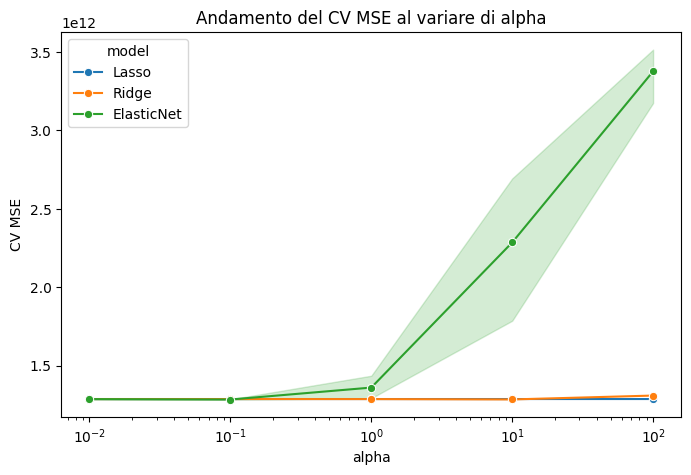

In [ ]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=results_df, x="alpha", y="cv_mse", hue="model", marker="o")
plt.xscale("log")
plt.ylabel("CV MSE")
plt.title("Andamento del CV MSE al variare di alpha")

plt.show()

Proseguo e:
- Riaddestro i modelli sull'intero dataset di train con i migliori valori trovati per i parametri.
- Confronto i coefficienti non nulli dei modelli.

In [ ]:
# Metodo per verificare i coefficienti > 0
def count_not_null_coefficients(pipe):
    coefficients = pipe.named_steps["model"].coef_
    return np.sum(np.abs(coefficients) > 0)

# Addestramento su intero dataset di train
# Applico sempre la standardizzazione Z-score
lasso_model = Pipeline([
  ("scaler", StandardScaler()),
  ("model", Lasso(alpha=best_lasso_alpha))])

ridge_model = Pipeline([
  ("scaler", StandardScaler()),
  ("model", Ridge(alpha=best_ridge_alpha))])

elasticnet_model = Pipeline([
  ("scaler", StandardScaler()),
  ("model", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio))])

lasso_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
elasticnet_model.fit(X_train, y_train)

not_null_coefficients = pd.DataFrame({
    "model": ["Lasso", "Ridge", "ElasticNet"],
    "non_zero_coefficients": [
        count_not_null_coefficients(lasso_model),
        count_not_null_coefficients(ridge_model),
        count_not_null_coefficients(elasticnet_model)]})

print(not_null_coefficients)

        model  non_zero_coefficients
0       Lasso                     12
1       Ridge                     12
2  ElasticNet                     12


Noto che in realtà tutti i modelli stanno utilizzando tutte le feature che quindi immagino siano tutte significative. Per cui in nessun modello è stata ridotta la complessità scartando delle feature.

Proseguo e valuto i modelli sul dataset di test.

In [ ]:
# Valutazione
print("R2 LASSO test:", lasso_model.score(X_test, y_test))
print("R2 RIDGE test:", ridge_model.score(X_test, y_test))
print("R2 ELASTICNET test:", elasticnet_model.score(X_test, y_test))

R2 LASSO test: 0.692215452816771
R2 RIDGE test: 0.6942576067907494
R2 ELASTICNET test: 0.6974876297561929


I Valori di R2 non sono altissimi.

Proseguo valutando anche i residui rispetto ai valori predetti:

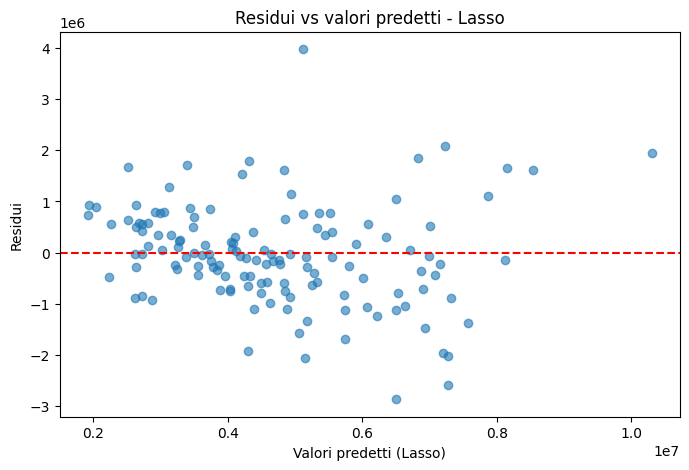

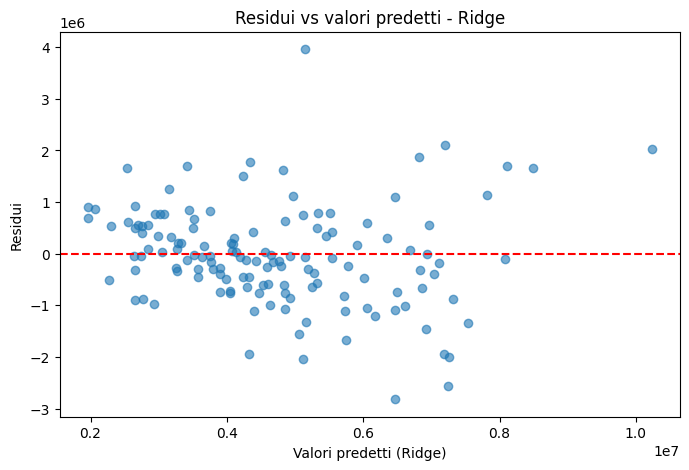

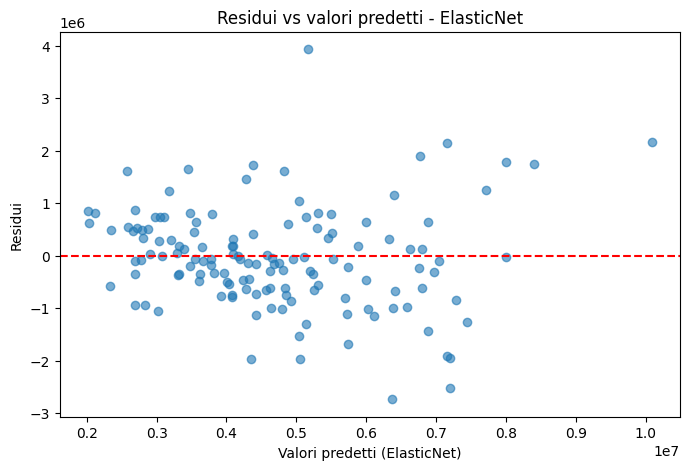

In [ ]:
# Metodo per plottare grafico dei residui
def plot_residuals_vs_predicted(model, X, y, model_name="Model"):
  y_pred = model.predict(X)
  residuals = y - y_pred

  plt.figure(figsize=(8, 5))
  plt.scatter(y_pred, residuals, alpha=0.6)
  plt.axhline(y=0, color="red", linestyle="--")
  plt.xlabel(f"Valori predetti ({model_name})")
  plt.ylabel("Residui")
  plt.title(f"Residui vs valori predetti - {model_name}")
  plt.show()

plot_residuals_vs_predicted(lasso_model, X_test, y_test, "Lasso")
plot_residuals_vs_predicted(ridge_model, X_test, y_test, "Ridge")
plot_residuals_vs_predicted(elasticnet_model, X_test, y_test, "ElasticNet")

Noto che i residui sembrano sparsi in maniera randomica attorno alla linea rossa che indica lo 0, per cui non vedo pattern particolari che mi fanno pensare ad una rappresentazione dei dati non buona.

Continuo visualizzando anche il grafico dei valori predetti rispetto ai reali.

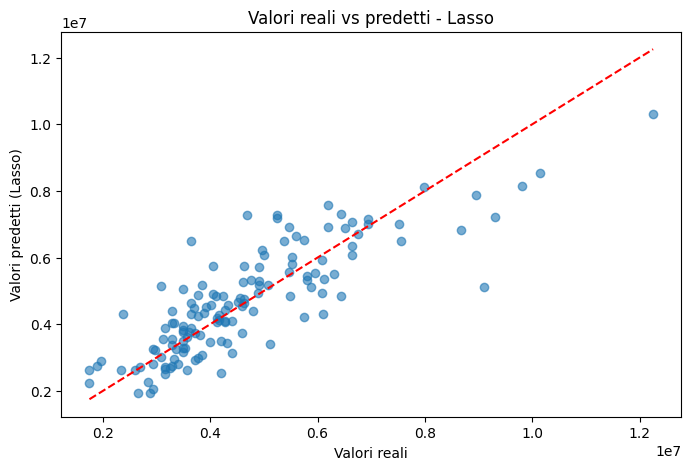

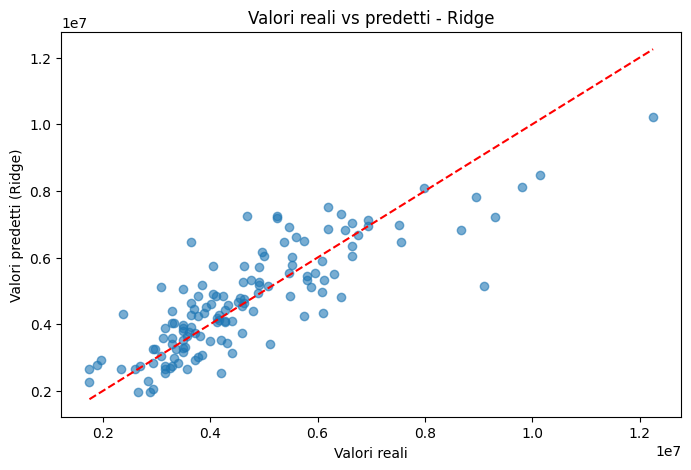

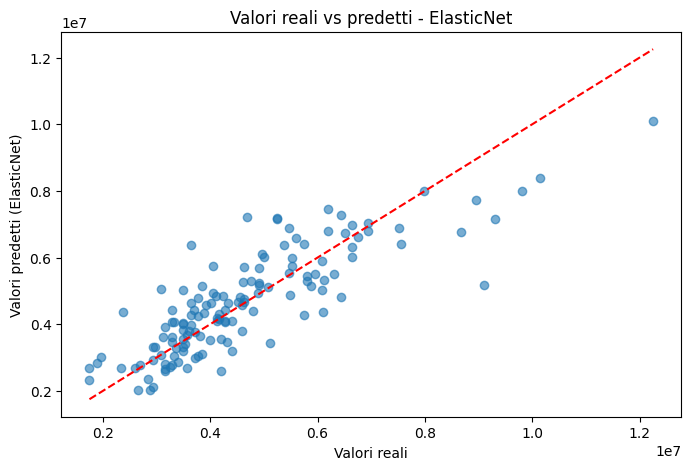

In [ ]:
# Metodo per plottare grafico predetti vs reali
def plot_predicted_vs_real(model, X, y, model_name="Model"):
  y_pred = model.predict(X)

  plt.figure(figsize=(8, 5))
  plt.scatter(y, y_pred, alpha=0.6)

  min_val = min(y.min(), y_pred.min())
  max_val = max(y.max(), y_pred.max())

  plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
  plt.xlabel("Valori reali")
  plt.ylabel(f"Valori predetti ({model_name})")
  plt.title(f"Valori reali vs predetti - {model_name}")
  plt.show()

plot_predicted_vs_real(lasso_model, X_test, y_test, "Lasso")
plot_predicted_vs_real(ridge_model, X_test, y_test, "Ridge")
plot_predicted_vs_real(elasticnet_model, X_test, y_test, "ElasticNet")

Le rette mi sembrano piuttosto coerenti.

Valuto anche le learning curve.

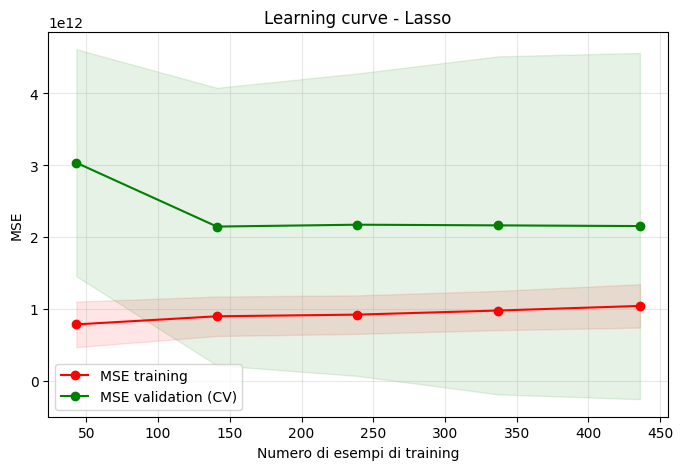

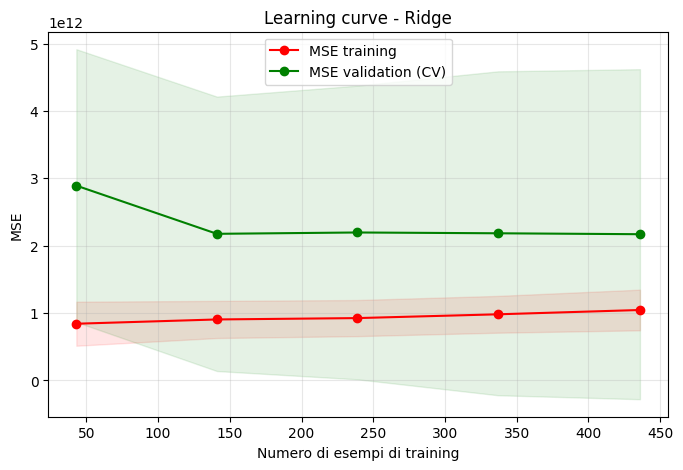

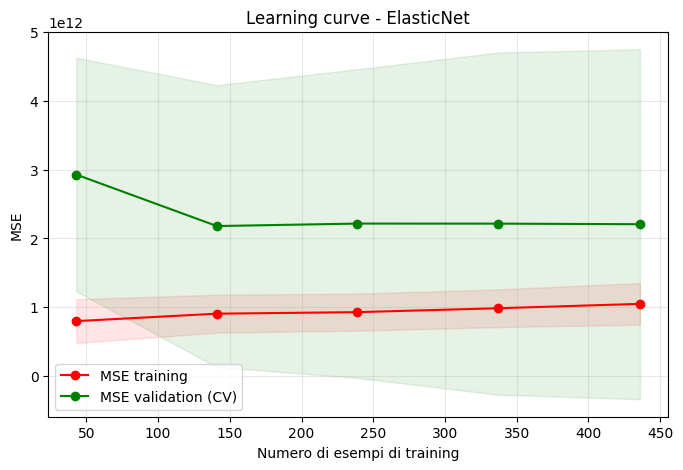

In [ ]:
# Metodo per plottare learning curve
def plot_learning_curve(estimator, X, y, model_name="Model", train_sizes=np.linspace(0.1, 1.0, 5)):
  train_sizes, train_scores, valid_scores = learning_curve(
    estimator=estimator,
    X=X,
    y=y,
    scoring=NEG_MEAN_SQUARED_ERROR,
    train_sizes=train_sizes,
    n_jobs=-1,
    shuffle=True,
    random_state=SEED)

  train_scores = -train_scores
  valid_scores = -valid_scores

  train_mean = train_scores.mean(axis=1)
  train_std = train_scores.std(axis=1)
  valid_mean = valid_scores.mean(axis=1)
  valid_std = valid_scores.std(axis=1)

  plt.figure(figsize=(8, 5))
  plt.title(f"Learning curve - {model_name}")
  plt.xlabel("Numero di esempi di training")
  plt.ylabel("MSE")
  plt.grid(True, alpha=0.3)

  plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1,
    color="r")

  plt.fill_between(
    train_sizes,
    valid_mean - valid_std,
    valid_mean + valid_std,
    alpha=0.1,
    color="g")

  plt.plot(
    train_sizes,
    train_mean,
    "o-",
    color="r",
    label="MSE training")

  plt.plot(
      train_sizes,
      valid_mean,
      "o-",
      color="g",
      label="MSE validation (CV)")

  plt.legend(loc="best")
  plt.show()

lasso_estimator_lc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=best_lasso_alpha))])

ridge_estimator_lc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_ridge_alpha))])

elasticnet_estimator_lc = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=best_elasticnet_alpha, l1_ratio=best_elasticnet_l1_ratio))])

plot_learning_curve(lasso_estimator_lc, X, y, model_name="Lasso")
plot_learning_curve(ridge_estimator_lc, X, y, model_name="Ridge")
plot_learning_curve(elasticnet_estimator_lc, X, y, model_name="ElasticNet")

# Confronto con altri modelli di regressione lineare
Per curiosità provo a fare un confronto anche tramite:
- Un modello di regressione lineare semplice con la feature più correlata.
- Un modello di regressione lineare multipla con le feature più correlate (2 feature).
- Modelli di regressione lineare polinomiale (con e senza bias).

Proseguo con:
- Regressione lineare semplice.
- Regressione lineare multipla.
- Regressione lineare polinomiale.

(Non splitto il dataset in train/test)

Abbiamo già detto che le features più correlate sono:
- area
- bathrooms

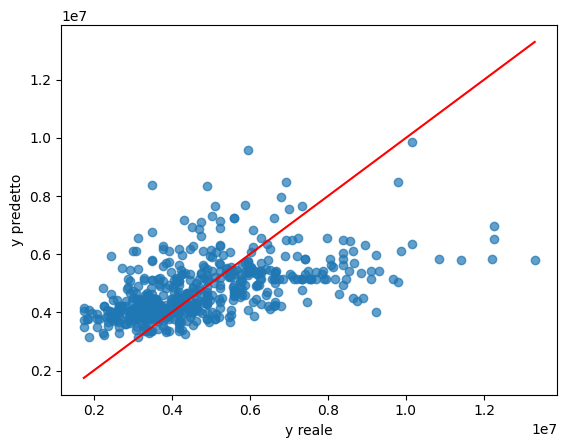



MSE = 2488861398180.6567
R2 = 0.2872931546811469




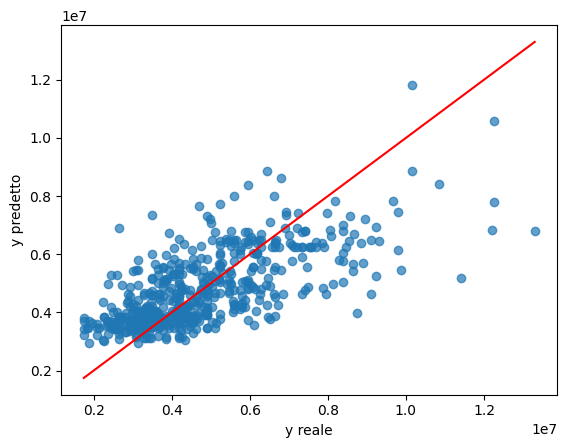



MSE = 1867988197696.7175
R2 = 0.46508553009562104


In [ ]:
# Funzione generica di valutazione di un modello
def evaluate(model, data):
    x, y = data
    y_pred = model.predict(x)

    mse = mean_squared_error(y, y_pred)

    plt.scatter(y, y_pred, alpha=0.7)
    plt.xlabel("y reale")
    plt.ylabel("y predetto")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")  # linea perfetta
    plt.show()

    print("\n")
    print(f"MSE = {mse}")
    print(f"R2 = {r2_score(y, y_pred)}")

# Regressione lineare semplice
X_lr_simple = df[[AREA_FEATURE]].values

lr_simple = LinearRegression()
lr_simple.fit(X_lr_simple, y)

evaluate(lr_simple, (X_lr_simple, y))

print("\n")

# Regressione lineare multipla
X_lr_multiple = df[[AREA_FEATURE, BATHROOMS_FEATURE]].values

lr_multiple = LinearRegression()
lr_multiple.fit(X_lr_multiple, y)

evaluate(lr_multiple, (X_lr_multiple, y))

Polinomio di grado 2 con bias


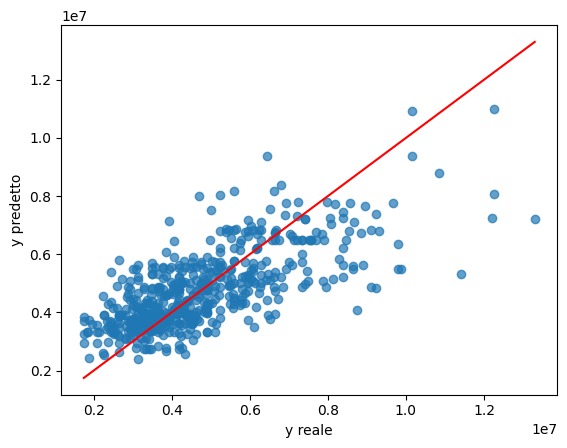



MSE = 1735623401171.7168
R2 = 0.5029893268404158
----------

Polinomio di grado 3 con bias


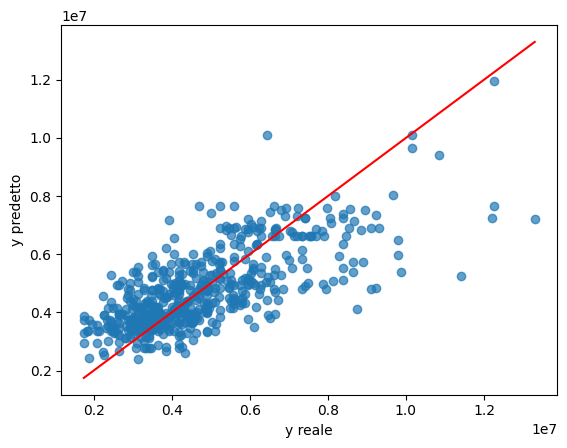



MSE = 1707857919453.239
R2 = 0.5109402110876462
----------

Polinomio di grado 4 con bias


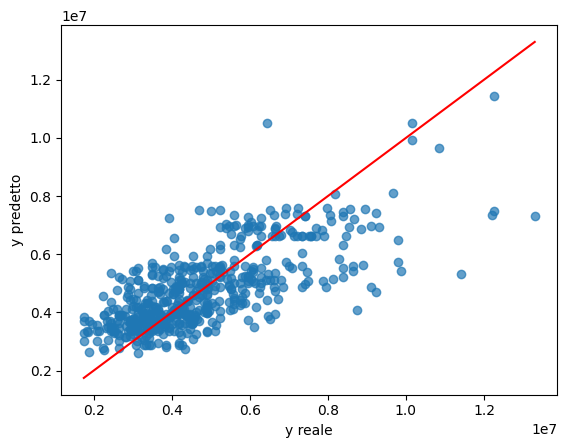



MSE = 1700723617729.468
R2 = 0.5129831796831728
----------

Polinomio di grado 5 con bias


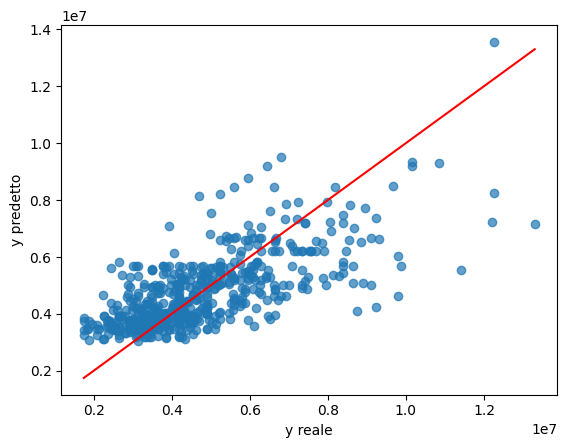



MSE = 1810490378603.5117
R2 = 0.4815505246061985
----------

Polinomio di grado 2 senza bias


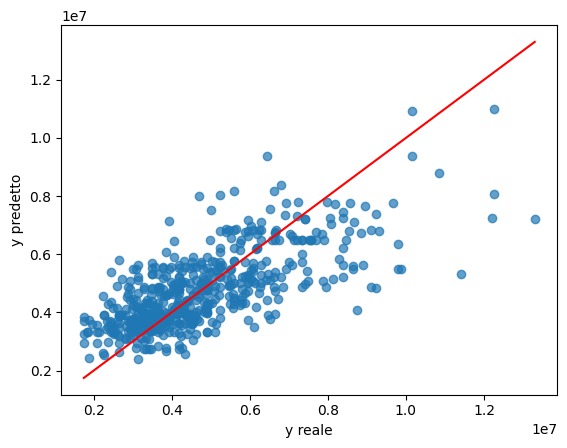



MSE = 1735623401171.7166
R2 = 0.5029893268404158
----------

Polinomio di grado 3 senza bias


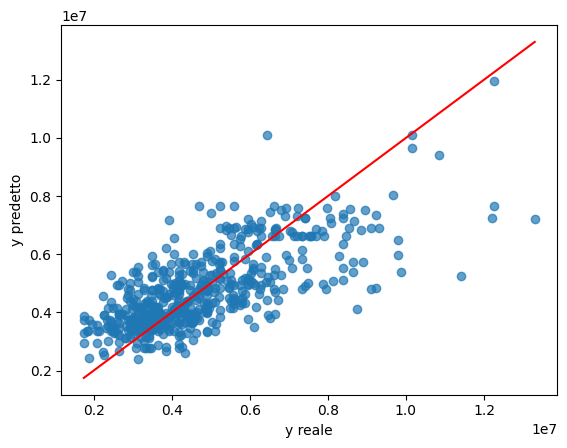



MSE = 1707857918663.3677
R2 = 0.5109402113138326
----------

Polinomio di grado 4 senza bias


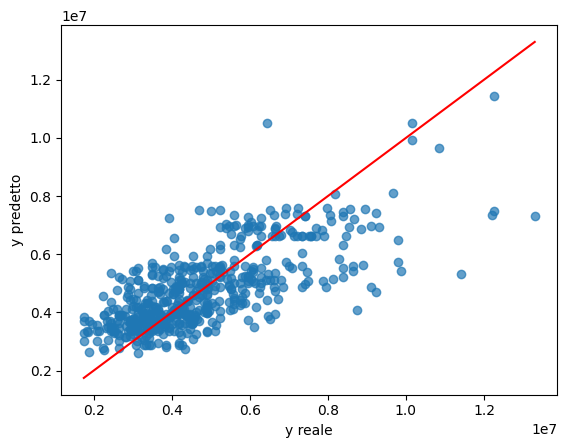



MSE = 1700723579749.9993
R2 = 0.51298319055892
----------

Polinomio di grado 5 senza bias


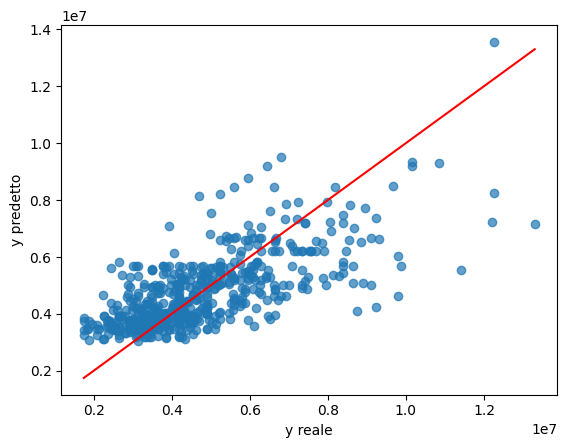



MSE = 1810490378600.991
R2 = 0.4815505246069204
----------



In [ ]:
# Regressione polinomiale con bias
for i in range(2, 6):
    print(f"Polinomio di grado {i} con bias")

    polynomial = PolynomialFeatures(i)
    X_poly = polynomial.fit_transform(X_lr_multiple)

    lr = LinearRegression()
    lr.fit(X_poly, y)

    evaluate(lr, (X_poly, y))

    print("----------\n")

# Regressione polinomiale senza bias
for i in range(2, 6):
    print(f"Polinomio di grado {i} senza bias")

    polynomial = PolynomialFeatures(i, include_bias=False)
    X_poly = polynomial.fit_transform(X_lr_multiple)

    lr = LinearRegression()
    lr.fit(X_poly, y)

    evaluate(lr, (X_poly, y))

    print("----------\n")

Mi aspettavo chiaramente degli R2 più bassi.

I modelli con tecniche di regolarizzazione sono i migliori.